# CISC 886 — Cloud Computing Project
## Notebook 2: Fine-Tuning (QLoRA)

**Purpose:** Fine-tune `unsloth/Llama-3.2-3B-Instruct` on Stack Overflow Q&A pairs using QLoRA.

**Input:** `train.parquet`, `val.parquet`, and `test.parquet` — produced by **Notebook 1** and uploaded here.

> ⚠️ **Before running:** Runtime → Change runtime type → **T4 GPU**

## Cell 1 — Install Dependencies

In [1]:



%%capture
!pip install unsloth
!pip install --upgrade --no-cache-dir "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install pandas pyarrow matplotlib
print('✅ All dependencies installed')

## Cell 2 — Configuration

In [2]:
import os

MODEL_NAME     = 'unsloth/Llama-3.2-3B-Instruct'
MAX_SEQ_LENGTH = 1024
LOAD_IN_4BIT   = True
MODEL_OUTPUT   = 'stackoverflow-chatbot-lora'
GGUF_OUTPUT    = 'stackoverflow-chatbot-gguf'

# ── Input: parquet files from Notebook 1 ─────────────────────────────────────
# Upload train.parquet, val.parquet, test.parquet via the Files panel
TRAIN_PARQUET  = 'train.parquet'
VAL_PARQUET    = 'val.parquet'
TEST_PARQUET   = 'test.parquet'

os.makedirs(MODEL_OUTPUT, exist_ok=True)
os.makedirs(GGUF_OUTPUT,  exist_ok=True)
print('✅ Configuration ready')

✅ Configuration ready


## Cell 3 — Load Data from Parquet
> Upload `train.parquet`, `val.parquet`, and `test.parquet` (output of Notebook 1) via the Files panel on the left.

In [3]:
import pandas as pd

df_train = pd.read_parquet(TRAIN_PARQUET)
df_val   = pd.read_parquet(VAL_PARQUET)
df_test  = pd.read_parquet(TEST_PARQUET)

print(f'✅ Train:      {len(df_train):,} samples')
print(f'✅ Validation: {len(df_val):,} samples')
print(f'✅ Test:       {len(df_test):,} samples')
print(f'\n📋 Columns: {list(df_train.columns)}')
print(f'\n📝 Sample row:')
print(df_train[['instruction','input','output']].iloc[0].to_string())

✅ Train:      20,000 samples
✅ Validation: 2,000 samples
✅ Test:       2,000 samples

📋 Columns: ['question_id', 'instruction', 'input', 'output', 'question_score', 'answer_score', 'tags', 'created_at', 'input_len', 'output_len']

📝 Sample row:
instruction    You are a helpful technical assistant. Answer ...
input          Question: How do I print out the results of my...
output         The overall easiest way if you just need a log...


## Cell 4 — Load Base Model (4-bit QLoRA)

In [4]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name    = MODEL_NAME,
    max_seq_length= MAX_SEQ_LENGTH,
    dtype         = None,
    load_in_4bit  = LOAD_IN_4BIT,
)
print(f'✅ Base model loaded: {MODEL_NAME}')
print( '   Parameters:    ~3 Billion')
print( '   Quantization:  4-bit NF4')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-3b-instruct-unsloth-bnb-4bit as a legacy tokenizer.


✅ Base model loaded: unsloth/Llama-3.2-3B-Instruct
   Parameters:    ~3 Billion
   Quantization:  4-bit NF4


## Cell 5 — Attach LoRA Adapter

In [5]:
# LoRA inserts small trainable matrices into the frozen base model.
# Only ~10-20M parameters are trained instead of the full 3B.
model = FastLanguageModel.get_peft_model(
    model,
    r                        = 16,
    target_modules           = ['q_proj','k_proj','v_proj','o_proj',
                                 'gate_proj','up_proj','down_proj'],
    lora_alpha               = 16,
    lora_dropout             = 0,
    bias                     = 'none',
    use_gradient_checkpointing= 'unsloth',
    random_state             = 42,
    use_rslora               = False,
    loftq_config             = None,
)
print('✅ LoRA adapter attached')
model.print_trainable_parameters()

Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


✅ LoRA adapter attached
trainable params: 24,313,856 || all params: 3,237,063,680 || trainable%: 0.7511


## Cell 6 — Format Dataset in Alpaca Style

In [6]:
from datasets import Dataset

ALPACA_PROMPT = """Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

EOS_TOKEN = tokenizer.eos_token

def format_samples(examples):
    texts = []
    for instruction, inp, output in zip(
            examples['instruction'], examples['input'], examples['output']):
        texts.append(ALPACA_PROMPT.format(
            instruction=instruction, input=inp, output=output) + EOS_TOKEN)
    return {'text': texts}

hf_train = Dataset.from_pandas(df_train[['instruction','input','output']].reset_index(drop=True))
hf_val   = Dataset.from_pandas(df_val  [['instruction','input','output']].reset_index(drop=True))
hf_test  = Dataset.from_pandas(df_test [['instruction','input','output']].reset_index(drop=True))
hf_train = hf_train.map(format_samples, batched=True)
hf_val   = hf_val  .map(format_samples, batched=True)
hf_test  = hf_test .map(format_samples, batched=True)

print(f'✅ Train:      {len(hf_train):,} samples formatted')
print(f'✅ Validation: {len(hf_val):,} samples formatted')
print(f'✅ Test:       {len(hf_test):,} samples formatted')
print('\n📝 Example prompt (first 400 chars):')
print(hf_train[0]['text'][:400], '...')

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Train:      20,000 samples formatted
✅ Validation: 2,000 samples formatted
✅ Test:       2,000 samples formatted

📝 Example prompt (first 400 chars):
Below is an instruction that describes a task, paired with an input that provides further context. Write a response that appropriately completes the request.

### Instruction:
You are a helpful technical assistant. Answer the following programming question.

### Input:
Question: How do I print out the results of my delete script in Powershell

Details: I'm trying to find a way to get my script to  ...


## Cell 7 — Base Model Inference (Before Fine-Tuning)
> Run inference on the base model **before** training. Responses are saved for the before/after comparison required by the assignment.

In [7]:
FastLanguageModel.for_inference(model)

def run_inference(prompt_input, max_new_tokens=256):
    full_prompt = ALPACA_PROMPT.format(
        instruction='You are a helpful technical assistant. Answer the following programming question clearly and concisely.',
        input=prompt_input,
        output='',
    )
    inputs  = tokenizer(full_prompt, return_tensors='pt').to('cuda')
    outputs = model.generate(**inputs, max_new_tokens=max_new_tokens, use_cache=True)
    return tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()

PROMPT_1 = 'Question: How do I reverse a list in Python?\n\nDetails: I have a list [1,2,3] and want [3,2,1].'
PROMPT_2 = 'Question: What is the difference between == and === in JavaScript?\n\nDetails: When should I use each?'

print('=' * 60)
print('BASE MODEL — Prompt 1:')
print('=' * 60)
base_response_1 = run_inference(PROMPT_1)
print(base_response_1)

print('\n' + '=' * 60)
print('BASE MODEL — Prompt 2:')
print('=' * 60)
base_response_2 = run_inference(PROMPT_2)
print(base_response_2)

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BASE MODEL — Prompt 1:


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) 

You can reverse a list in Python using the `reversed()` function in combination with the `list()` function. Here's how you can do it:

```python
my_list = [1, 2, 3]
reversed_list = list(reversed(my_list))
print(reversed_list)  # Outputs: [3, 2, 1]
```

Alternatively, you can use slicing to reverse the list. Here's how you can do it:

```python
my_list = [1, 2, 3]
reversed_list = my_list[::-1]
print(reversed_list)  # Outputs: [3, 2, 1]
```

Both methods will give you the same result, but the slicing method is generally more efficient because it avoids the overhead of the `reversed()` function.

BASE MODEL — Prompt 2:
In JavaScript, `==` and `==` (also known as loose equality) are often confused with each other. However, they have different behaviors.

- `==` checks for value equality. This means it will compare the actual values of two variables, regardless of their data types. For example, `5 == '5'` would return `true` because the values are equal, but `5 == 5` would return `true` bec

## Cell 8 — Fine-Tune with SFTTrainer

| Parameter | Value | Reason |
|---|---|---|
| learning_rate | 2e-4 | Standard LoRA LR |
| per_device_train_batch_size | 2 | Fits T4 16GB |
| gradient_accumulation_steps | 4 | Effective batch = 8 |
| num_train_epochs | 1 | Avoids overfitting |
| warmup_steps | 50 | Stable LR warmup |
| lr_scheduler_type | cosine | Smooth LR decay |
| LoRA r | 16 | Capacity vs memory |
| LoRA alpha | 16 | Equal to r |
| Quantization | 4-bit NF4 | VRAM reduction |
| optimizer | adamw_8bit | Memory efficient |

In [8]:
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

trainer = SFTTrainer(
    model              = model,
    tokenizer          = tokenizer,
    train_dataset      = hf_train,
    eval_dataset       = hf_val,
    dataset_text_field = 'text',
    max_seq_length     = MAX_SEQ_LENGTH,
    dataset_num_proc   = 2,
    args = TrainingArguments(
        per_device_train_batch_size  = 1,
        gradient_accumulation_steps  = 8,
        warmup_steps                 = 50,
        num_train_epochs             = 1,
        learning_rate                = 2e-4,
        fp16                         = not is_bfloat16_supported(),
        bf16                         = is_bfloat16_supported(),
        logging_steps                = 10,
        eval_steps                   = 100,
        eval_strategy          = 'steps',
        lr_scheduler_type            = 'cosine',
        optim                        = 'adamw_8bit',
        seed                         = 42,
        output_dir                   = '/content/training_checkpoints',
    ),
)

print('✅ Trainer configured — starting fine-tuning...')
print('   Estimated time: 1-2 hours on T4 GPU')
trainer_stats = trainer.train()

print(f'\n✅ Fine-tuning complete!')
print(f"   Time: {trainer_stats.metrics['train_runtime']:.0f} seconds")
print(f"   Loss: {trainer_stats.metrics['train_loss']:.4f}")

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Trainer configured — starting fine-tuning...
   Estimated time: 1-2 hours on T4 GPU


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 20,000 | Num Epochs = 1 | Total steps = 2,500
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 24,313,856 of 3,237,063,680 (0.75% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
100,1.797825,1.872372
200,1.820510,1.857820
300,1.777649,1.847528
400,1.953291,1.842348
500,1.824328,1.837218
600,1.780293,1.834993
700,1.783326,1.830592
800,1.822892,1.827994
900,1.798796,1.825119
1000,1.763391,1.822273


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Unsloth: Restored added_tokens_decoder metadata in /content/training_checkpoints/checkpoint-500/tokenizer_config.json.
/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils


✅ Fine-tuning complete!
   Time: 18517 seconds
   Loss: 1.7990


## Cell 9 — Training Loss Curve

In [12]:
print(trainer.state.global_step)

2500


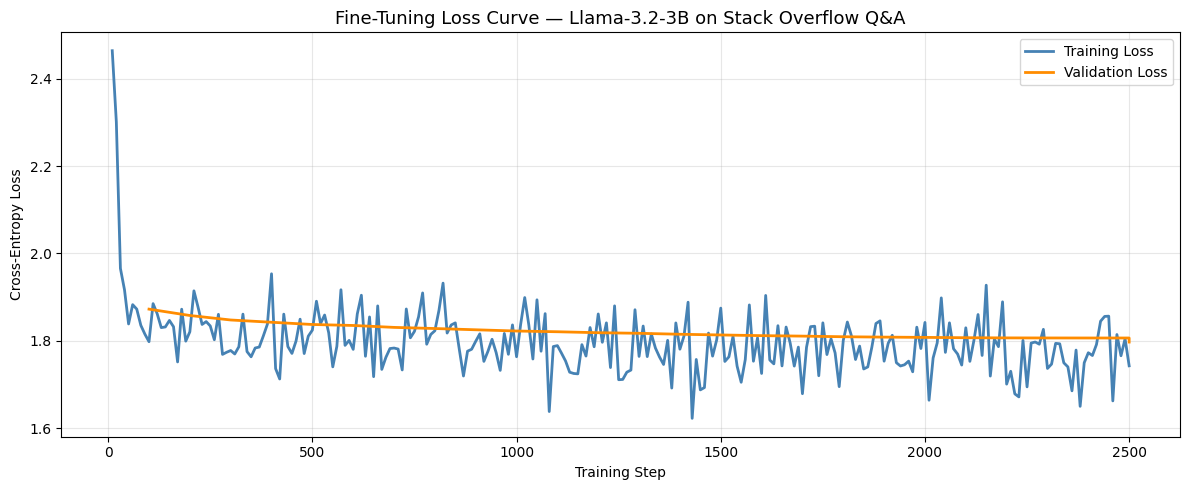

✅ Loss curve saved


In [23]:
import matplotlib.pyplot as plt

log_history  = trainer.state.log_history
train_steps  = [x['step']      for x in log_history if 'loss'      in x]
train_losses = [x['loss']      for x in log_history if 'loss'      in x]
eval_steps   = [x['step']      for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(train_steps,  train_losses, label='Training Loss',   color='steelblue',  linewidth=2)
ax.plot(eval_steps,   eval_losses,  label='Validation Loss', color='darkorange', linewidth=2)
ax.set_title('Fine-Tuning Loss Curve — Llama-3.2-3B on Stack Overflow Q&A', fontsize=13)
ax.set_xlabel('Training Step')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Loss curve saved')

## Cell 10 — Test Set Evaluation
> Compute the final loss on the held-out **test set** after training is complete.  
> This is the number to report in the assignment — the model never saw this data during training.

In [17]:
import torch
import math

# tokenization (زي ما عملتي)
def tokenize_and_label(examples):
    tokenized = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        padding=False,
    )
    tokenized['labels'] = tokenized['input_ids'].copy()
    return tokenized

print("🔄 Tokenizing test set...")
hf_test_tokenized = hf_test.map(
    tokenize_and_label,
    batched=True,
    remove_columns=hf_test.column_names,
)

print("🔍 Evaluating manually...")

model = trainer.model
model.eval()

total_loss = 0
count = 0

with torch.no_grad():
    for sample in hf_test_tokenized:
        input_ids = torch.tensor(sample["input_ids"]).unsqueeze(0).to(model.device)
        labels = torch.tensor(sample["labels"]).unsqueeze(0).to(model.device)

        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss

        total_loss += loss.item()
        count += 1

avg_loss = total_loss / count
perplexity = math.exp(avg_loss)

print(f"\n📊 Test Set Results:")
print(f"   Loss: {avg_loss:.4f}")
print(f"   Perplexity: {perplexity:.2f}")

🔄 Tokenizing test set...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

🔍 Evaluating manually...

📊 Test Set Results:
   Loss: 1.8023
   Perplexity: 6.06


## Cell 11 — Fine-Tuned Model Inference (After Training)

In [18]:
FastLanguageModel.for_inference(model)

print('=' * 60)
print('FINE-TUNED MODEL — Prompt 1:')
print('=' * 60)
ft_response_1 = run_inference(PROMPT_1)
print(ft_response_1)

print('\n' + '=' * 60)
print('FINE-TUNED MODEL — Prompt 2:')
print('=' * 60)
ft_response_2 = run_inference(PROMPT_2)
print(ft_response_2)

# Side-by-side comparison for the report
print('\n' + '=' * 60)
print('SIDE-BY-SIDE COMPARISON')
print('=' * 60)
print(f'\n[Prompt 1] Reverse a list in Python')
print(f'\n  BASE MODEL:\n{base_response_1[:400]}')
print(f'\n  FINE-TUNED:\n{ft_response_1[:400]}')
print(f'\n[Prompt 2] == vs === in JavaScript')
print(f'\n  BASE MODEL:\n{base_response_2[:400]}')
print(f'\n  FINE-TUNED:\n{ft_response_2[:400]}')

Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


FINE-TUNED MODEL — Prompt 1:


Both `max_new_tokens` (=256) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You can use the [reversed]([URL] function to get the list reversed: >>> list(reversed([1,2,3])) [3, 2, 1] Or use slicing: >>> list([1,2,3][::-1]) [3, 2, 1]

FINE-TUNED MODEL — Prompt 2:
== checks for value equality, === checks for reference equality. The former is useful when you want to compare the actual value of a variable. For example, if you have a variable foo with a string, and you want to check if the variable is a string, you would use ==. If you want to check if the variable is the same object as a string, you would use ===. This is useful when you have a variable that is a function, and you want to check if the variable is a function. For example, if you have a variable foo with a function, and you want to check if the variable is a function, you would use ===. === is useful when you want to check if the variable is the same object as another variable. For example, if you have two variables foo and bar, and you want to check if they are the same object, you would use ===. Th

## Cell 12 — Save LoRA Adapter

In [19]:
# Save only the LoRA adapter weights (~100-200 MB).
# Base model weights stay unchanged.
model.save_pretrained(MODEL_OUTPUT)
tokenizer.save_pretrained(MODEL_OUTPUT)
print(f'✅ LoRA adapter saved to: {MODEL_OUTPUT}')

Unsloth: Restored added_tokens_decoder metadata in stackoverflow-chatbot-lora/tokenizer_config.json.


✅ LoRA adapter saved to: stackoverflow-chatbot-lora


## Cell 13 — Export to GGUF for Ollama

In [20]:
# Export to GGUF format for Ollama on EC2.
# q4_k_m: 4-bit quantization, ~2GB, good quality/size balance.
model.save_pretrained_gguf(GGUF_OUTPUT, tokenizer, quantization_method='q4_k_m')
print(f'✅ GGUF model saved to: {GGUF_OUTPUT}')
print('   Ready to upload to EC2 for Ollama deployment')

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in stackoverflow-chatbot-gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /teamspace/studios/this_studio/.cache/huggingface/hub


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Unsloth: Merge process complete. Saved to `/teamspace/studios/this_studio/outputs/stackoverflow-chatbot-gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Missing packages: libcurl4-openssl-dev libssl-dev
Unsloth: Will attempt to install missing system packages.
Unsloth: Installing packages: libcurl4-openssl-dev libssl-dev


Missing system packages. We need to execute `sudo apt-get install libcurl4-openssl-dev libssl-dev -y` - do you accept? Press ENTER. Type NO if not. 


Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['stackoverflow-chatbot-gguf_gguf/llama-3.2-3b-instruct.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['stackoverflow-chatbot-gguf_gguf/llama-3.2-3b-instruct.Q4_K_M.gguf']
Unsloth: example usage for text only LLMs: /teamspace/studios/this_studio/.unsloth/llama.cpp/llama-cli --model stackoverflow-chatbot-gguf_gguf/llama-3.2-3b-instruct.Q4_K_M.gguf -p "why is the sky blue?"
Unsloth: Saved Ollama Modelfile to stackoverflow-chatbot-gguf_gguf/Modelfile
Unsloth: convert model to ollama format by running - ollama create model_name -f stackoverflow-chatbot-gguf_gguf/Modelfile
✅ GGUF model saved to: stackoverflow-chatbot-gguf
   Ready to upload to EC2 for Ollama deployment
